<a href="https://colab.research.google.com/github/Rmendivil94/retail-fraud-detection/blob/main/01_EDA_and_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IEEE-CIS Fraud Detection: Exploratory Data Analysis

In [ ]:
# Loading the Kaggle token / Cargando el token de Kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rodrigomendivil","key":"eb440019d11b04a83fccc0aa683fd856"}'}

In [ ]:
# Downloading "ieee-fraud-detection" dataset / Descargando conjunto de datos "ieee-fraud-detection"
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c ieee-fraud-detection
!unzip ieee-fraud-detection.zip -d data/

  0% 0.00/118M [00:00<?, ?B/s]
100% 118M/118M [00:00<00:00, 1.40GB/s]
Archive:  ieee-fraud-detection.zip
  inflating: data/sample_submission.csv  
  inflating: data/test_identity.csv  
  inflating: data/test_transaction.csv  
  inflating: data/train_identity.csv  
  inflating: data/train_transaction.csv  


In [ ]:
# Initial setup / Congfiguración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Optimizing usage of RAM memory / Optimizando el uso de memoria RAM
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print('Memory usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

## Preparing dataset | Preparando el conjunto de datos

In [ ]:
# 1. Load the data / Cargar los datos
print("Loading data... /Cargando datos...")
train_transaction = pd.read_csv('data/train_transaction.csv')
train_identity = pd.read_csv('data/train_identity.csv')

# 2. Merging with Left Join on Transaction ID / Unión con Left Join usando TransactionID
print("Merging tables / Fusionando tablas...")
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# 3. Reduce memory usage from original df's / Liberar memoria de los df originales
del train_transaction, train_identity
import gc
gc.collect()

# 4. Applying memory reduction function to the final df / Aplicar la reducción de memoria al df final
print("Optimizing memory... /Optimizando memoria...")
train = reduce_mem_usage(train)

# 5. Preview data / Vista inicial
train.head()

Loading data... /Cargando datos...
Merging tables / Fusionando tablas...
Optimizing memory... /Optimizando memoria...


/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_235/1372050007.py:20: RuntimeWarning:

Memory usage decreased to 645.97 Mb (67.0% reduction)


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## NULLS Analysis | Análisis de nulos

In [ ]:
# 1. Nulls percentage per column / Calcular el porcentaje de nulos por columna
missing_percentages = (train.isnull().sum() / len(train)) * 100

# Columns with at least 1 null sorted descending / Columnas con al menos 1 nulo ordenadas de mayor a menor
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending = False)

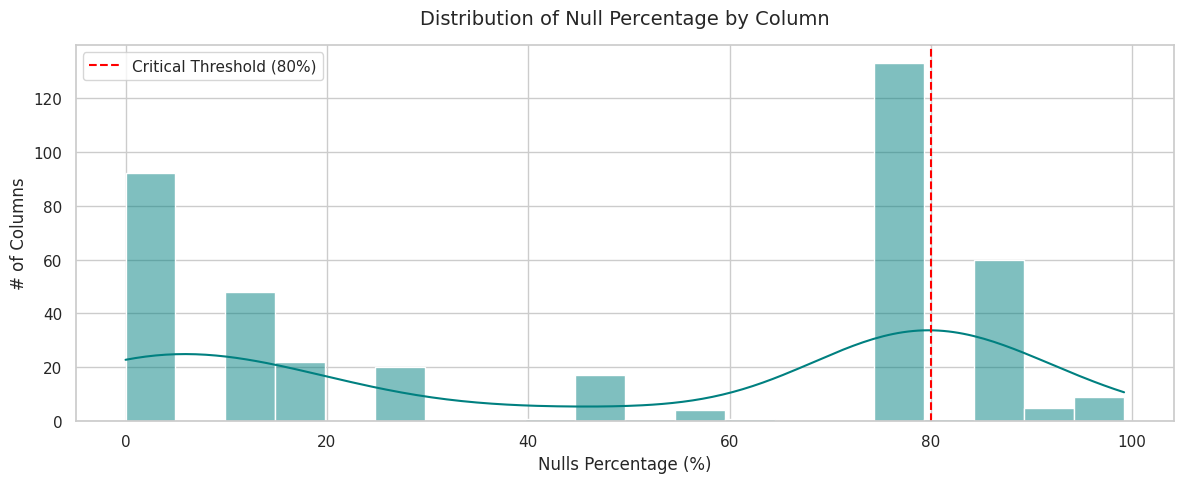

In [ ]:
# 2. Visual setup / Configuración visual
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Graphic A: Null Distribution / Gráfico A: Distribución de nulos
plt.figure(figsize = (12, 5))
sns.histplot(missing_percentages, bins = 20, kde = True, color = 'teal')
plt.title('Distribution of Null Percentage by Column', fontsize = 14, pad = 15)
plt.xlabel('Nulls Percentage (%)', fontsize = 12)
plt.ylabel('# of Columns', fontsize = 12)
# Draw a red line at 80% as a threshold
plt.axvline(x = 80, color='red', linestyle = '--', label = 'Critical Threshold (80%)')
plt.legend()
plt.tight_layout()
plt.show()

#### EN: More than 120 columns exceed 70% missing values, so the threshold is set at 70%   
#### ES: Más de 120 columnas superan el 70% de valores perdidos, por lo que el umbral se fija en 70%

In [ ]:
# Summary of Nulls | Resumen de nulos
print(f"Total columns with at least one missing value: {len(missing_percentages)}")
print(f"Columns with more than 70% of missing values: {sum(missing_percentages > 70)}")

Total columns with at least one missing value: 414
Columns with more than 70% of missing values: 208


# Drop > 70% null columns | Eliminar columnas > 70% vacías

#### EN: In transactional data, null values can also be part of fraudulent behavior, so the variable "nulls_count" is created before deleting columns with more than 70% null values, in order to keep information that the nulls could provide.
#### ES: En data transaccional, los valores nulos también pueden formar parte del comportamiento fraudulento, por lo que se crea la variable "nulls_count" antes de eliminar las columnas con más del 70% de valores nulos, esto con el fin de mantener la información que los nulos podrían aportar.

In [ ]:
# 1. Counting nulls per row | Conteo de nulos por fila
train['nulls_count'] = train.isnull().sum(axis = 1)

# 2. Treshold | Umbral (70% = 0.70)
treshold = 0.70

# 3. Proportion of nulls that exceed the threshold | Proporción de nulos que superan el umbral
missing_ratios = train.isnull().mean()
columns_to_drop = missing_ratios[missing_ratios > treshold].index

# 4. Drop columns | Eliminar columnas
train = train.drop(columns = columns_to_drop)

# 5. Results | Resultados
print(f"Elimination treshold applied: > {treshold * 100}% of nulls")
print(f"Dropped columns: {len(columns_to_drop)}")
print(f"New shape of train dataset: {train.shape}")

/tmp/ipykernel_235/3928522961.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['nulls_count'] = train.isnull().sum(axis = 1)


Elimination treshold applied: > 70.0% of nulls
Dropped columns: 208
New shape of train dataset: (590540, 227)


# Target variable analysis | Análisis de variable objetivo

In [ ]:
# 1. Fraud count and Percentage | Conteo y porcentajes de fraude
fraud_counts = train['isFraud'].value_counts()
fraud_rates = train['isFraud'].value_counts(normalize = True) * 100

print("--- Target Variable Distribution (isFraud) ---")
print(f"Non Fraudulent Transactions (0): {fraud_counts[0]} ({fraud_rates[0]:.2f}%)")
print(f"Fraudulent Transactions (1): {fraud_counts[1]} ({fraud_rates[1]:.2f}%)")
print("-" * 52)

# 2. Visual Setting | Configuración visual
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Barplot | Gráfico de barras
ax = sns.countplot(x='isFraud', data=train, palette=['#2ca02c', '#d62728'])
plt.title('Desbalanceo de Clases: Legítimo vs. Fraude', fontsize=14, pad=15)
plt.xlabel('Clase (0 = Legítimo, 1 = Fraude)', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)

# 3. Añadir las etiquetas de porcentaje encima de las barras
for p in ax.patches:
    height = p.get_height()
    total = len(train)
    ax.annotate(f'{height/total:.2%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()